<a href="https://colab.research.google.com/github/koherrera97/kevin_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



from google.colab import files
uploaded = files.upload ()
dataset = pd.read_csv("car_purchase_data.csv")
dataset.head()

Saving car_purchase_data.csv to car_purchase_data (4).csv


,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Step 2: Split features and target

In [52]:
X = dataset[['Age', 'Salary']]
y = dataset['Purchased']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Age  Salary
0   19   19000
1   35   20000
2   26   43000
3   27   57000
4   19   76000

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


### Step 3: Train/Test Split

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)


print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (300, 2)
Testing set size: (100, 2)


### Step 4: Feature Scaling

In [55]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Scaled X_train (first 5 rows):")
print(X_train[:5])

print("\nScaled X_test (first 5 rows):")
print(X_test[:5])

Scaled X_train (first 5 rows):
[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]]

Scaled X_test (first 5 rows):
[[-0.80480212  0.50496393]
 [-0.01254409 -0.5677824 ]
 [-0.30964085  0.1570462 ]
 [-0.80480212  0.27301877]
 [-0.30964085 -0.5677824 ]]


### Step 5: Train Logistic Regression Model

In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### Step 6: Predict and Evaluate

In [63]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

Confusion Matrix:
[[65  3]
 [ 8 24]]

Accuracy Score:
0.89


### Step 7: Visualization of Decision Regions

/tmp/ipykernel_6305/2164164407.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


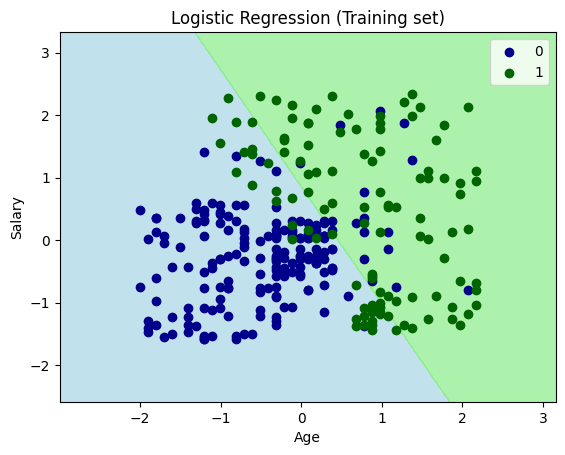

In [61]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('lightblue', 'lightgreen'))
)

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('darkblue', 'darkgreen'))(i),
        label=j
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend()
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1.) Logistic regression predicts probability between 0 and 1 using the sigmoid function. To turn this into a classification a threshold should be applied typically around 0.5. So even though this may throw out probabilites depending on where the threshold is it classifies the information by assigning labels on the cutoff.

2.) Based on the model created, people who are older and have higher salaries are more likely to buy a car in contrast to those with lower salaries and younger, who are less likely to buy a car.

3.) Limited available data can definitely cause for low accuracy also overlapping data can cause for low accuracy as well as noise in the data, imbalance etc.

4.) More Data, things along the lines of Marital Status, Credit Score, location, region all play a big factor when making the decision of whether or not to buy a vehicle as well as purchase history number of dependents etc.